**Hypothesis 2: Class standing and AI Use Frequency are correlated.**  

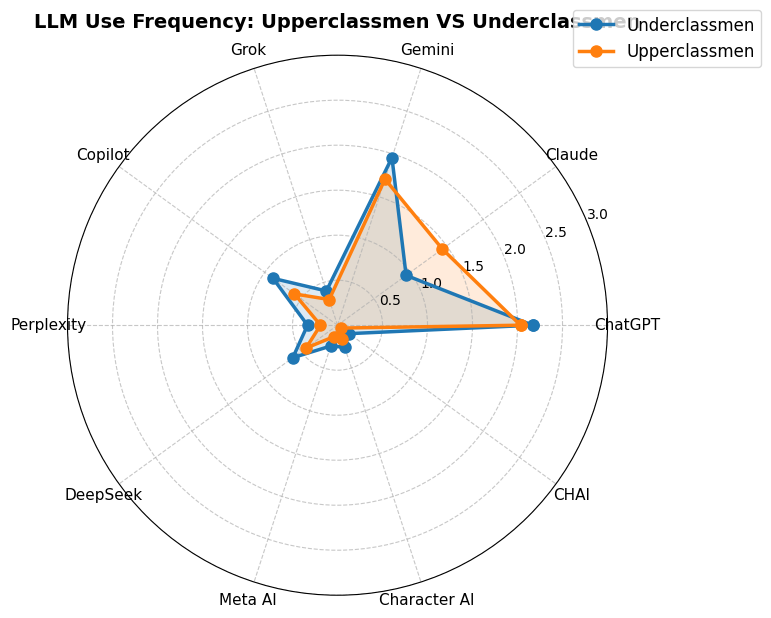

In [8]:
#I USED BOTH THE LAB 5-6 GUIDE FOR HELP WITH SETTING UP THE 
#SPIDER CHART AS WELL AS CLAUDE FOR HELP MAPPING/REPLACING THE DATA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


data_df = pd.read_csv("data.csv")

#map class standing to upper/underclassmen
standing_map = {'Freshman': 'Underclassmen', 'Sophomore': 'Underclassmen', 'Junior': 'Upperclassmen', 'Senior': 'Upperclassmen'}

data_df['standing_group'] = data_df['What is your current class standing?'].map(standing_map) 

#mapping frequency to numbers
freq_map = {'Never Used': 0, 'Used 1-2 times': 1, 'Use Rarely': 2, 'Use Frequently': 3}

#llm columns from data
llm_cols = [
    'How frequently do you use the following Large Learning Models (LLMs)? [ChatGPT]',
    'How frequently do you use the following Large Learning Models (LLMs)? [Claude]',
    'How frequently do you use the following Large Learning Models (LLMs)? [Gemini]',
    'How frequently do you use the following Large Learning Models (LLMs)? [Grok]',
    'How frequently do you use the following Large Learning Models (LLMs)? [Copilot]',
    'How frequently do you use the following Large Learning Models (LLMs)? [Perplexity]',
    'How frequently do you use the following Large Learning Models (LLMs)? [DeepSeek]',
    'How frequently do you use the following Large Learning Models (LLMs)? [Meta AI]',
    'How frequently do you use the following Large Learning Models (LLMs)? [Character AI]',
    'How frequently do you use the following Large Learning Models (LLMs)? [CHAI]'
]

#replace to numeric values 
data_df[llm_cols] = data_df[llm_cols].replace(freq_map)

#mean frequency for each standing group
group_means = data_df.groupby('standing_group')[llm_cols].mean()
group_names = group_means.index.tolist() 

# Set up the radar chart geometry
num_metrics = len(llm_cols)  # Number of metrics (4 in this case)

# Create evenly spaced angles for each axis (in radians)
# endpoint=False means we don't duplicate the starting angle
theta = np.linspace(0, 2*np.pi, num_metrics, endpoint=False)

# Close the polygon by appending the first angle at the end
theta = np.concatenate((theta, [theta[0]]))

# Create the polar plot
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, polar=True)  # polar=True creates a circular plot

colors = ['#1f77b4', '#ff7f0e']

for i, group in enumerate(group_names):
    # Get the mean values for this species across all 4 metrics
    values = group_means.loc[group].values

    # Close the polygon by appending the first value at the end
    values = np.concatenate((values, [values[0]]))

    # Plot the line connecting all points
    ax.plot(theta, values, linewidth=2.5, linestyle='solid',
            label=group.capitalize(), color=colors[i], marker='o', markersize=8)

    # Fill the area inside the polygon with transparency
    ax.fill(theta, values, alpha=0.15, color=colors[i])

# Customize the plot
ax.set_xticks(theta[:-1])  # Set tick positions (exclude the duplicate last point)
ax.set_xticklabels(['ChatGPT', 'Claude', 'Gemini', 'Grok', 'Copilot', 'Perplexity', 'DeepSeek', 'Meta AI', 'Character AI', 'CHAI'],
                   fontsize=11)
ax.set_ylim(0, 3)  # Set radial axis limits to accommodate the data range
ax.grid(True, linestyle='--', alpha=0.7)

# Add legend and title
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)
ax.set_title('LLM Use Frequency: Upperclassmen VS Underclassmen',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

**This visualization displays the LLMs favored by the two class standings. For example, Upperclassmen use Claude more frequently than Underclassmen. Overall, Underclassmen have higher mean usage frequency of LLMs than Upperclassmen.**

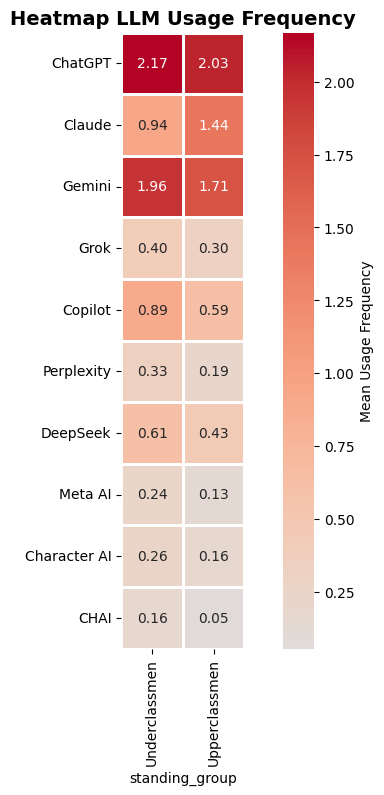

In [9]:
#I USED BOTH THE LAB 5-6 GUIDE TO REFERENCE HOW TO SET UP THE HEATMAP AND ASKED CLAUDE FOR HELP SETTING THE ROWS TO THE LLMS AND 
#THE COLS TO THE CLASS STADING

import seaborn as sns

# Select only numeric columns for correlation analysis (excluding 'Gender' which is categorical)
numeric_df = data_df[llm_cols]

#rename columns
llm_names = ['ChatGPT', 'Claude', 'Gemini', 'Grok', 'Copilot','Perplexity', 'DeepSeek', 'Meta AI', 'Character AI', 'CHAI']


#transpose operation, which flips the rows and columns so that
#llm names can be the rows and the class standing can be cols
heat_map = group_means.T
heat_map.index = llm_names



# Set figure size for better readability
plt.figure(figsize=(10, 8))

# Create the heatmap
sns.heatmap(heat_map, center=0, cmap='coolwarm', annot=True, fmt='.2f',
            square=True, linewidths=1, cbar_kws={'label': 'Mean Usage Frequency'})

# Add title
plt.title('Heatmap LLM Usage Frequency', fontsize=14, fontweight='bold')

# Display the plot
plt.show()

# Interpretation:
# - Values close to +1 (dark red): Strong positive correlation
# - Values close to -1 (dark blue): Strong negative correlation
# - Values close to 0 (white): Little to no correlation

**This heatmap provides a better visual of which class standing has the overall higher mean usage frequency. For all values besides Claude, Underclassmen have a higher mean usage frequency than Upperclassmen.**

In [ ]:
#I used the example from the Lab 5-6 guide and asked Claude for help with iterating through the different 
#LLMS for each indiviudal test
from scipy.stats import chi2_contingency, chi2

llm_names = ['ChatGPT', 'Claude', 'Gemini', 'Grok', 'Copilot','Perplexity', 'DeepSeek', 'Meta AI', 'Character AI', 'CHAI']

freq_labels = {0: 'Never Used', 1: 'Used 1-2 Times', 2: 'Use Rarely', 3: 'Use Frequently'}

for col, name in zip(llm_cols, llm_names):

    #Create the contingency table
    contingency = pd.crosstab(data_df['standing_group'], data_df[col])
    contingency.columns = [freq_labels[c] for c in contingency.columns]

    print(f"\nCONTINGENCY TABLE: {name} Usage by Class Standing")
    print("=" * 60)
    print(contingency)
    print("\nRow Totals:", contingency.sum(axis=1).values, "(Underclassmen, Upperclassmen)")
    print("Column Totals:", contingency.sum(axis=0).values)
    print("Grand Total:", contingency.sum().sum(), "students surveyed")

  

    #Perform Chi-Square Test
    chi_stat, p_value, degrees_freedom, expected_freq = chi2_contingency(contingency)
    expected = pd.DataFrame(expected_freq, index=contingency.index, columns=contingency.columns)



    #Display test results
    critical_value = chi2.ppf(0.95, degrees_freedom)
    print("\n" + "=" * 60)
    print(f"CHI-SQUARE TEST RESULTS: {name}")
    print("=" * 60)
    print(f"Chi-Square Statistic (χ²): {chi_stat:.4f}")
    print(f"P-value: {p_value:.6f}")
    print(f"Degrees of Freedom: {degrees_freedom}")
    print(f"\nSignificance Level: α = 0.05")
    print(f"Critical Value at α=0.05: {critical_value:.4f}")

    # Step 5: Interpret the results
    print("\n" + "=" * 60)
    print("INTERPRETATION")
    print("=" * 60)

    if p_value < 0.05:
        print("✓ REJECT the null hypothesis (independence)")
        print(f"  → The p-value ({p_value:.6f}) is less than 0.05")
        print(f"  → The χ² statistic ({chi_stat:.4f}) exceeds the critical value ({critical_value:.4f})")
        print(f"\n  CONCLUSION: Class standing and {name} usage ARE associated!")
        print(f"  There is a statistically significant relationship.")
    else:
        print("✗ FAIL TO REJECT the null hypothesis")
        print(f"  → The p-value ({p_value:.6f}) is greater than 0.05")
        print(f"  → The χ² statistic ({chi_stat:.4f}) is below the critical value ({critical_value:.4f})")
        print(f"\n  CONCLUSION: Cannot conclude that class standing and {name} usage are associated.")
        print("  The data is consistent with independence.")



CONTINGENCY TABLE: ChatGPT Usage by Class Standing
                Never Used  Used 1-2 Times  Use Rarely  Use Frequently
standing_group                                                        
Underclassmen            5              12          20              34
Upperclassmen           17              24          46              63

Row Totals: [ 71 150] (Underclassmen, Upperclassmen)
Column Totals: [22 36 66 97]
Grand Total: 221 students surveyed

CHI-SQUARE TEST RESULTS: ChatGPT
Chi-Square Statistic (χ²): 1.3966
P-value: 0.706326
Degrees of Freedom: 3

Significance Level: α = 0.05
Critical Value at α=0.05: 7.8147

INTERPRETATION
✗ FAIL TO REJECT the null hypothesis
  → The p-value (0.706326) is greater than 0.05
  → The χ² statistic (1.3966) is below the critical value (7.8147)

  CONCLUSION: Cannot conclude that class standing and ChatGPT usage are associated.
  The data is consistent with independence.

CONTINGENCY TABLE: Claude Usage by Class Standing
                Never Used 

**After performing the test on each LLM, we cannot conclude for most LLMS (7/10) that they are correlated. Despite visualizations, the test shows us that class standing and LLM mean frequency usage are likely not correlated. The conclusion leads to fail to reject the null hypothesis. However, I still believe there is interesting information to take away with the 3 LLMS that are associated with class standing. For instance, Claude is associated with class standing and is used significantly more frequently by upperclassmen then underclassmen.**
